In [2]:
%cd 170A-CHOC

[WinError 2] The system cannot find the file specified: '170A-CHOC'
c:\Users\anony\Coding projects\170A-CHOC\decision_tree_classifier


In [4]:

from data.data_partitioner import DataPartitioner

In [5]:
data = DataPartitioner(data_dir='data')
data.load_datasets()

In [6]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [7]:
# Use CHOC+SVI+COI data for all splits so the tree trains on the full feature space
full_df = data.choc_svi_coi.copy()

# 70/15/15 split with stratification on the target
train_df, temp_df = train_test_split(
    full_df,
    test_size=0.30,
    random_state=42,
    stratify=full_df["no_show"],
)

df_test, df_eval = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["no_show"],
)

df = train_df.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_eval = df_eval.reset_index(drop=True)

print("Shapes -> train:", df.shape, "test:", df_test.shape, "eval:", df_eval.shape)

Shapes -> train: (321569, 190) test: (68908, 190) eval: (68908, 190)


In [8]:
# Use the full feature set from the data dictionary, excluding the target column
feature_cols = [col for col in df.columns if col != "no_show"]

def add_tree_features(frame, ref_medians=None):
    enriched = frame.copy()
    # Ratios that capture appointment history more directly than raw counts
    enriched["cancel_rate_365"] = enriched["CANCELS_365"] / (enriched["APPTS_365"] + 1)
    enriched["noshow_rate_365"] = enriched["NOSHOWS_365"] / (enriched["APPTS_365"] + 1)
    enriched["resched_rate_365"] = enriched["RESCHEDS_365"] / (enriched["APPTS_365"] + 1)
    enriched["primary_care_share_365"] = enriched["PRIMARY_CARE_365"] / (enriched["APPTS_365"] + 1)
    enriched["book_to_appt_per_day"] = enriched["BOOK_TO_APPT"] / (enriched["DURATION"] + 1)
    enriched["history_burden"] = enriched["CANCELS_365"] + enriched["RESCHEDS_365"] + enriched["NOSHOWS_365"]
    enriched["history_rate"] = enriched["history_burden"] / (enriched["APPTS_365"] + 1)

    med_appts = ref_medians["APPTS_365"] if ref_medians is not None else enriched["APPTS_365"].median()
    med_burden = ref_medians["history_burden"] if ref_medians is not None else enriched["history_burden"].median()
    enriched["recent_utilizer"] = (enriched["APPTS_365"] >= med_appts).astype(int)
    enriched["high_history_burden"] = (enriched["history_burden"] >= med_burden).astype(int)
    return enriched

# Build train first so derived-threshold features use only train statistics
train_base = df[feature_cols].copy()
train_tmp = add_tree_features(train_base)
ref_medians = {
    "APPTS_365": train_tmp["APPTS_365"].median(),
    "history_burden": train_tmp["history_burden"].median(),
}

df_features = add_tree_features(train_base, ref_medians)
df_test_features = add_tree_features(df_test[feature_cols].copy(), ref_medians)
df_eval_features = add_tree_features(df_eval[feature_cols].copy(), ref_medians)

# Convert categorical columns into dummy variables
df_enc = pd.get_dummies(df_features, drop_first=False)
df_test_enc = pd.get_dummies(df_test_features, drop_first=False)
df_eval_enc = pd.get_dummies(df_eval_features, drop_first=False)

# Align test/eval columns to the training set so all splits use the same feature layout
df_test_enc = df_test_enc.reindex(columns=df_enc.columns, fill_value=0)
df_eval_enc = df_eval_enc.reindex(columns=df_enc.columns, fill_value=0)

In [9]:
# Build the target vectors from the original splits
y_train = (df['no_show'] == 'Yes').astype(int)
y_test = (df_test['no_show'] == 'Yes').astype(int)
y_eval = (df_eval['no_show'] == 'Yes').astype(int)

# Feature matrices use the full encoded set, including the historical 365-day usage variables
X_train = df_enc
X_test = df_test_enc
X_eval = df_eval_enc

In [10]:
# Use RFECV to select features, then run RandomizedSearchCV on the reduced set
from sklearn.feature_selection import RFECV
from sklearn.model_selection import train_test_split

base_tree = DecisionTreeClassifier(random_state=42)

# RFECV on a larger stratified sample to get more stable feature selection
X_rfecv, _, y_rfecv, _ = train_test_split(
    X_train,
    y_train,
    train_size=0.50,
    random_state=42,
    stratify=y_train,
)
print('RFECV sample shape:', X_rfecv.shape)

# Smaller step size and min_features_to_select to avoid collapsing to 1 feature
rfecv = RFECV(
    estimator=DecisionTreeClassifier(random_state=42),
    step=0.10,
    min_features_to_select=max(10, int(0.05 * len(X_train.columns))),
    cv=StratifiedKFold(n_splits=3),
    scoring='accuracy',
    n_jobs=-1,
)
rfecv.fit(X_rfecv, y_rfecv)
support = rfecv.support_
selected_cols = X_train.columns[support].tolist()
print('RFECV selected', len(selected_cols), 'features')

# Create reduced feature matrices for subsequent tuning and downstream steps
X_train_sel = X_train[selected_cols].copy()
X_test_sel = X_test[selected_cols].copy()
X_eval_sel = X_eval[selected_cols].copy()

# Keep the original hyperparameter search but fit on the selected feature subset
param_distributions = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [8, 10, 12, 14, 16, 20, None],
    "min_samples_split": [2, 5, 10, 20, 50],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "max_features": [None, "sqrt", "log2"],
    "max_leaf_nodes": [None, 50, 100, 200, 400],
    "ccp_alpha": [0.0, 0.0001, 0.0005, 0.001],
    "class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
search = RandomizedSearchCV(
    estimator=base_tree,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=1,
)
search.fit(X_train_sel, y_train)

clf = search.best_estimator_
print("Best parameters:", search.best_params_)
print("Best cross-validated accuracy:", round(float(search.best_score_), 4))

print("Train accuracy:", round(float(accuracy_score(y_train, clf.predict(X_train_sel))), 4))
print("Test accuracy:", round(float(accuracy_score(y_test, clf.predict(X_test_sel))), 4))
print("Eval accuracy:", round(float(accuracy_score(y_eval, clf.predict(X_eval_sel))), 4))

RFECV sample shape: (160784, 261)
RFECV selected 183 features
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best parameters: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_leaf_nodes': 400, 'max_features': 'log2', 'max_depth': 12, 'criterion': 'gini', 'class_weight': None, 'ccp_alpha': 0.0001}
Best cross-validated accuracy: 0.8793
Train accuracy: 0.8793
Test accuracy: 0.8787
Eval accuracy: 0.8791


              precision    recall  f1-score   support

           0       0.88      1.00      0.94    281215
           1       0.76      0.06      0.10     40354

    accuracy                           0.88    321569
   macro avg       0.82      0.53      0.52    321569
weighted avg       0.86      0.88      0.83    321569



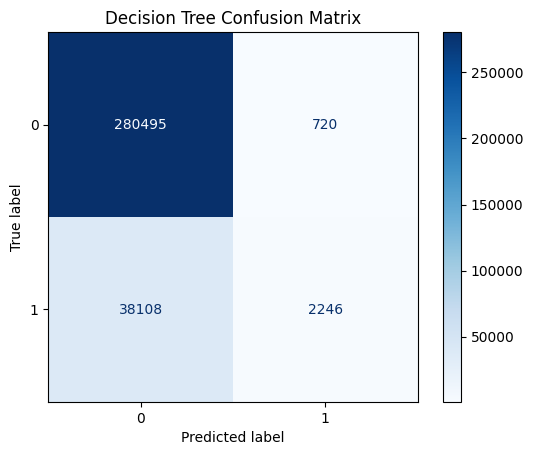

In [11]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred=clf.predict(X_train_sel)
print(classification_report(y_train, y_pred))
# 2. Compute the confusion matrix
cm = confusion_matrix(y_train, y_pred)

# 3. Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.grid(False)
plt.title("Decision Tree Confusion Matrix")
plt.show()

              precision    recall  f1-score   support

           0       0.88      1.00      0.93     60260
           1       0.73      0.05      0.10      8648

    accuracy                           0.88     68908
   macro avg       0.81      0.52      0.52     68908
weighted avg       0.86      0.88      0.83     68908



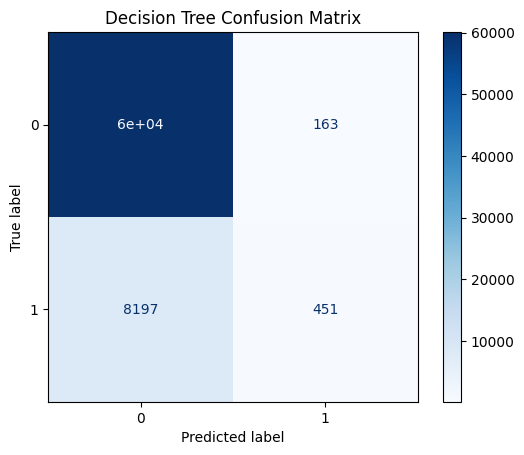

In [12]:
y_pred = clf.predict(X_test_sel)
print(classification_report(y_test, y_pred))
# 2. Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 3. Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.grid(False)
plt.title("Decision Tree Confusion Matrix")
plt.show()

              precision    recall  f1-score   support

           0       0.88      1.00      0.94     60261
           1       0.75      0.06      0.10      8647

    accuracy                           0.88     68908
   macro avg       0.82      0.53      0.52     68908
weighted avg       0.86      0.88      0.83     68908



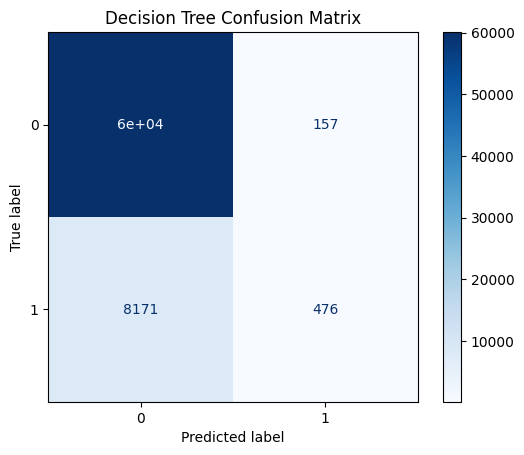

In [13]:
y_pred=clf.predict(X_eval_sel)
print(classification_report(y_eval, y_pred))
# 2. Compute the confusion matrix
cm = confusion_matrix(y_eval, y_pred)

# 3. Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.grid(False)
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [14]:
from sklearn.tree import export_text

# show_weights=True adds the counts for each class
# Use the RFECV-selected training columns for the export
rules = export_text(clf, feature_names=list(X_train_sel.columns), show_weights=True)
print(rules)

|--- INSURANCE_TYPE_Other/Unknown <= 0.50
|   |--- RPL_THEMES <= 0.60
|   |   |--- high_history_burden <= 0.50
|   |   |   |--- weights: [73138.00, 6365.00] class: 0
|   |   |--- high_history_burden >  0.50
|   |   |   |--- weights: [61635.00, 7507.00] class: 0
|   |--- RPL_THEMES >  0.60
|   |   |--- z_ED_nat <= 0.05
|   |   |   |--- weights: [126707.00, 21757.00] class: 0
|   |   |--- z_ED_nat >  0.05
|   |   |   |--- weights: [19015.00, 2479.00] class: 0
|--- INSURANCE_TYPE_Other/Unknown >  0.50
|   |--- weights: [720.00, 2246.00] class: 1



In [15]:

summary_df = df.pivot_table(
    index=['age', 
           'GENDER', 
           'RACE', 
           'ETHNICITY',
           'MOBILITY_ABILITY_DX_IND',
           'MENTAL_HEALTH_DX_IND',
           'INSURANCE_TYPE',
           ], 
    columns='no_show', 
    aggfunc='size', 
    fill_value=0
).reset_index()

# Rename columns for clarity
summary_df.columns.name = None
summary_df = summary_df.rename(columns={'No': 'indv_noshow_no', 'Yes': 'indv_noshow_yes'})

In [16]:
summary_df.shape

(4781, 9)

In [17]:
# Assuming 'clf' is your trained DecisionTreeClassifier
# and 'X_train_sel' is the RFECV-selected feature set used for that tree
df['leaf_id'] = clf.apply(X_train_sel)

In [18]:
# 1. Total count per leaf group
leaf_counts = df.groupby('leaf_id').size().rename('total_group_count')

# 2. Breakdown of shows vs no-shows per leaf
# Assuming 'noshow' column has values 'Yes' and 'No'
leaf_stats = df.groupby(['leaf_id', 'no_show']).size().unstack(fill_value=0)

# Rename columns for clarity
leaf_stats = leaf_stats.rename(columns={'No': 'group_show_count', 'Yes': 'group_noshow_count'})

In [19]:
# Join the total counts
df = df.merge(leaf_counts, on='leaf_id', how='left')

# Join the show/no-show breakdown
df = df.merge(leaf_stats, on='leaf_id', how='left')

# Optional: Calculate the probability/rate for that group
df['group_noshow_rate'] = df['group_noshow_count'] / df['total_group_count']

In [20]:
df_final = df.merge(summary_df, on= ['age', 
           'GENDER', 
           'RACE', 
           'ETHNICITY',
           'MOBILITY_ABILITY_DX_IND',
           'MENTAL_HEALTH_DX_IND',
           'INSURANCE_TYPE'
           ], how='left')

In [21]:
nndf = df_eval

In [22]:
nndf = nndf.merge(summary_df, on= ['age', 
           'GENDER', 
           'RACE', 
           'ETHNICITY',
           'MOBILITY_ABILITY_DX_IND',
           'MENTAL_HEALTH_DX_IND',
           'INSURANCE_TYPE'
           ], how='left')

In [23]:
# Apply the trained tree to the RFECV-selected eval feature set
nndf['leaf_id'] = clf.apply(X_eval_sel)

In [24]:
# Join the show/no-show breakdown
nndf = nndf.merge(leaf_stats, on='leaf_id', how='left')

In [25]:
nndf = nndf.fillna(0)

In [26]:
ndf = nndf[['no_show','indv_noshow_no','indv_noshow_yes', 'group_show_count','group_noshow_count']]

In [27]:
ndf['no_show'] = (ndf['no_show'] =='Yes').astype(int)

In [28]:
import torch
import numpy as np
import random
import os
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Beta
def set_seed(seed=42):
    # 1. Basic Python and NumPy seeds
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    
    # 2. PyTorch seeds
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # for multi-GPU
    
    # 3. Force CuDNN to be deterministic (Note: this can slightly slow down training)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
# 1. Prepare Inputs (Group counts and Individual counts)
# We often log-transform or scale counts so the NN handles them better
X = torch.tensor(ndf[['group_noshow_count', 'group_show_count', 
                    'indv_noshow_yes', 'indv_noshow_no']].values, dtype=torch.float32)

# 2. Prepare Target (1 for No-Show, 0 for Show)
# Ensure your 'no_show' column is 1/0
y = torch.tensor(ndf['no_show'].values, dtype=torch.float32).view(-1, 1)

In [29]:
class BayesianWeightNet(nn.Module):
    def __init__(self):
        super(BayesianWeightNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2), # Two weights: w_group and w_individual
        )

    def forward(self, x_raw):
        # Rates (Probabilities between 0 and 1)
        g_rate = x_raw[:, 0:1] / (x_raw[:, 0] + x_raw[:, 1] + 1e-6).view(-1, 1)
        i_rate = x_raw[:, 2:3] / (x_raw[:, 2] + x_raw[:, 3] + 1e-6).view(-1, 1)
        
        # NN Outputs
        phi = torch.sigmoid(self.net(torch.log1p(x_raw)))
        
        # DIFFERENTIAL SCALING:
        # Cap Group influence at 5 'effective appointments'
        # Cap Individual influence at 50 'effective appointments'
        w_g = phi[:, 0:1] * 15.0  
        w_i = phi[:, 1:2] * 50.0 
        
        # Now, if a person has 10 real appointments, 
        # they can easily 'outvote' the group's prior.
        alpha = (w_g * g_rate) + (w_i * i_rate) + 1.0
        beta_param = (w_g * (1-g_rate)) + (w_i * (1-i_rate)) + 1.0
        
        # Reparameterized Sampling
        dist = Beta(alpha, beta_param)
        p_hat = dist.rsample() 
        
        return p_hat, alpha, beta_param, w_g, w_i

In [30]:
model = BayesianWeightNet()
optimizer = optim.Adam(model.parameters(), lr=0.007)
criterion = nn.BCELoss()

for epoch in range(61):
    model.train()
    optimizer.zero_grad()
    
    # Catch the weights w_g (Group) and w_i (Individual)
    p_hat, a, b, wg, wi = model(X)
    
    loss = criterion(p_hat, y)
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        # We use .detach() so we don't accidentally keep the computation graph in memory
        avg_group_w = wg.mean().item()
        avg_indiv_w = wi.mean().item()
        max_group_w = wg.max().item()
        max_indiv_w = wi.max().item()

        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")
        print(f"   > Weights [Avg] - Group: {avg_group_w:.4f}, Indiv: {avg_indiv_w:.4f}")
        print(f"   > Weights [Max] - Group: {max_group_w:.4f}, Indiv: {max_indiv_w:.4f}")
        print(f"   > Posteriors    - Avg Alpha: {a.mean().item():.2f}, Avg Beta: {b.mean().item():.2f}")
        print("-" * 60)

Epoch   0 | Loss: 0.3752
   > Weights [Avg] - Group: 8.8576, Indiv: 33.8029
   > Weights [Max] - Group: 9.8854, Indiv: 35.4637
   > Posteriors    - Avg Alpha: 6.32, Avg Beta: 38.34
------------------------------------------------------------
Epoch  10 | Loss: 0.3720
   > Weights [Avg] - Group: 14.9648, Indiv: 49.3837
   > Weights [Max] - Group: 14.9842, Indiv: 49.7561
   > Posteriors    - Avg Alpha: 9.02, Avg Beta: 57.33
------------------------------------------------------------
Epoch  20 | Loss: 0.3717
   > Weights [Avg] - Group: 14.9987, Indiv: 47.6441
   > Weights [Max] - Group: 14.9997, Indiv: 49.2509
   > Posteriors    - Avg Alpha: 8.77, Avg Beta: 55.87
------------------------------------------------------------
Epoch  30 | Loss: 0.3696
   > Weights [Avg] - Group: 14.9996, Indiv: 46.5657
   > Weights [Max] - Group: 15.0000, Indiv: 49.7577
   > Posteriors    - Avg Alpha: 8.55, Avg Beta: 55.02
------------------------------------------------------------
Epoch  40 | Loss: 0.3706
 

In [31]:
model.eval()
with torch.no_grad():
    _, final_alphas, final_betas, _,_ = model(X)

# Add them back to your dataframe for analysis
ndf['posterior_alpha'] = final_alphas.numpy()
ndf['posterior_beta'] = final_betas.numpy()
ndf['predicted_risk'] = ndf['posterior_alpha'] / (ndf['posterior_alpha'] + ndf['posterior_beta'])

In [32]:
# Add them back to your dataframe for analysis
nndf['posterior_alpha'] = ndf['posterior_alpha']
nndf['posterior_beta'] = ndf['posterior_beta']
nndf['predicted_risk'] = ndf['predicted_risk']

In [33]:
# Usually use .pth or .pt extension
torch.save(model.state_dict(), 'decision_tree_classifier/himal_bayesian_weight_net.pth')

In [34]:
# 1. Re-instantiate the model class
model = BayesianWeightNet()

# 2. Load the weights
model.load_state_dict(torch.load('decision_tree_classifier/bayesian_weight_net.pth'))

# 3. ALWAYS set to eval mode if you're done training
model.eval()

BayesianWeightNet(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=2, bias=True)
  )
)

In [35]:
qq = ndf.groupby('predicted_risk').mean()['no_show'].reset_index()

In [36]:
qq

,predicted_risk,no_show
0,0.035145,0.000000
1,0.035251,0.000000
2,0.035487,0.000000
3,0.035618,0.200000
4,0.035911,0.000000
...,...,...
4687,0.851850,0.800000
4688,0.866407,1.000000
4689,0.869474,0.666667
4690,0.872770,1.000000


C:\Users\anony\AppData\Local\Temp\ipykernel_41888\2817159182.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


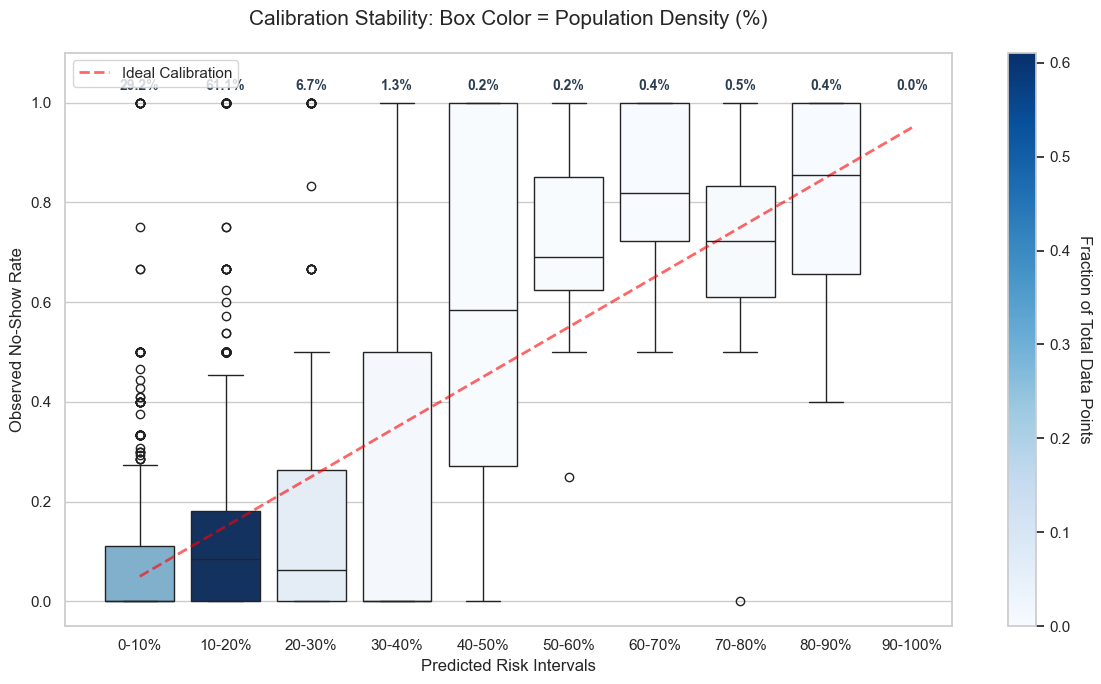

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# 1. Create 10% wide bins
bins = np.linspace(0, 1, 11)
labels = [f"{int(bins[i]*100)}-{int(bins[i+1]*100)}%" for i in range(len(bins)-1)]
qq['risk_bin'] = pd.cut(qq['predicted_risk'], bins=bins, labels=labels, include_lowest=True)

# 2. Calculate fractions (counts divided by total)
bin_counts = qq['risk_bin'].value_counts().sort_index()
bin_fractions = bin_counts / bin_counts.sum()  # Normalizing to get fractions (0 to 1)

# 3. Create a color palette based on fractions
# We use 'mako' or 'Blues' for a clean density look
norm = plt.Normalize(bin_fractions.min(), bin_fractions.max())
colors = [cm.Blues(norm(value)) for value in bin_fractions.values]

# 4. Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# 5. Create the Box Plot with the fraction-based palette
ax = sns.boxplot(
    data=qq, 
    x='risk_bin', 
    y='no_show', 
    palette=colors,
    showfliers=True
)

# 6. Add the Identity Line (The Target)
plt.plot(range(10), np.arange(0.05, 1.0, 0.1), 
         color='red', linestyle='--', linewidth=2, alpha=0.6, label='Ideal Calibration')

# 7. Add a Colorbar mapped to percentage
sm = plt.cm.ScalarMappable(cmap=cm.Blues, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Fraction of Total Data Points', rotation=270, labelpad=15)

# 8. Overlay the % text on each box for clarity
for i, fraction in enumerate(bin_fractions.values):
    plt.text(i, 1.02, f'{fraction:.1%}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2c3e50')

# 9. Clean up Labels
plt.title('Calibration Stability: Box Color = Population Density (%)', fontsize=15, pad=20)
plt.xlabel('Predicted Risk Intervals', fontsize=12)
plt.ylabel('Observed No-Show Rate', fontsize=12)
plt.ylim(-0.05, 1.1)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

C:\Users\anony\AppData\Local\Temp\ipykernel_41888\840115042.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


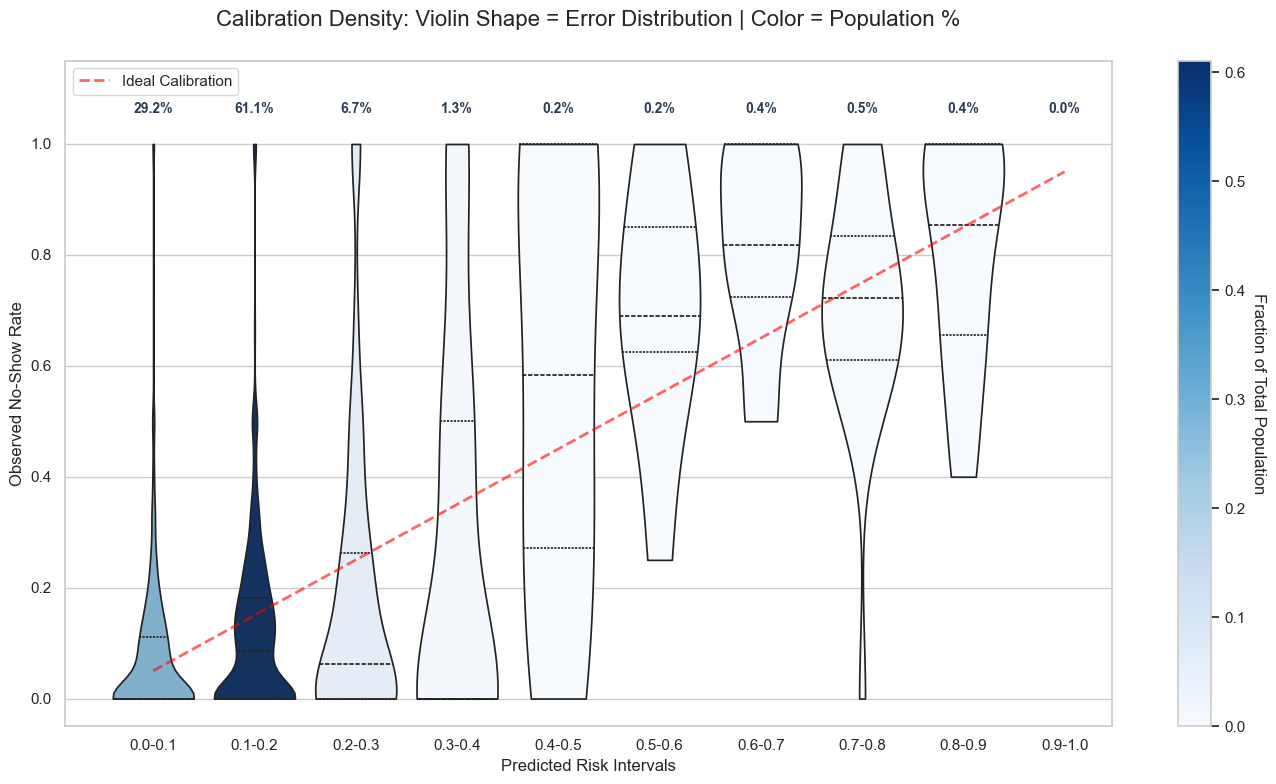

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# 1. Create 10% wide bins
bins = np.linspace(0, 1, 11)
labels = [f"{bins[i]:.1f}-{bins[i+1]:.1f}" for i in range(len(bins)-1)]
qq['risk_bin'] = pd.cut(qq['predicted_risk'], bins=bins, labels=labels, include_lowest=True)

# 2. Calculate fractions 
bin_counts = qq['risk_bin'].value_counts().sort_index()
bin_fractions = bin_counts / bin_counts.sum()

# 3. Create a color palette 
norm = plt.Normalize(bin_fractions.min(), bin_fractions.max())
colors = [cm.Blues(norm(value)) for value in bin_fractions.values]

# 4. Visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8))

# 5. THE VIOLIN PLOT
# inner="quartile" shows the internal stats
# cut=0 prevents the violin from extending beyond real data limits
ax = sns.violinplot(
    data=qq, 
    x='risk_bin', 
    y='no_show', 
    palette=colors,
    inner='quartile', 
    cut=0
)

# 6. Add the Identity Line
plt.plot(range(10), np.arange(0.05, 1.0, 0.1), 
         color='red', linestyle='--', linewidth=2, alpha=0.6, label='Ideal Calibration')

# 7. Add a Colorbar
sm = plt.cm.ScalarMappable(cmap=cm.Blues, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Fraction of Total Population', rotation=270, labelpad=15)

# 8. Overlay % text
for i, fraction in enumerate(bin_fractions.values):
    plt.text(i, 1.05, f'{fraction:.1%}', ha='center', va='bottom', 
             fontsize=10, fontweight='bold', color='#2c3e50')

# 9. Clean up
plt.title('Calibration Density: Violin Shape = Error Distribution | Color = Population %', fontsize=16, pad=25)
plt.xlabel('Predicted Risk Intervals', fontsize=12)
plt.ylabel('Observed No-Show Rate', fontsize=12)
plt.ylim(-0.05, 1.15) 
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

Brier Score: 0.1048
ROC-AUC: 0.6208
Log-Loss: 0.3620


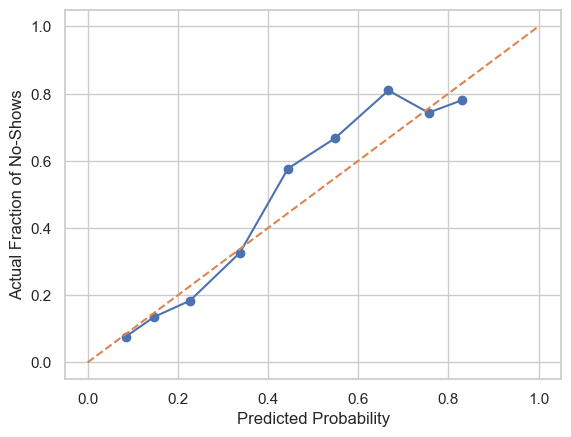

In [39]:
from sklearn.metrics import brier_score_loss, roc_auc_score, log_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
y_true = ndf['no_show']
y_prob = ndf['predicted_risk']
# Metrics
print(f"Brier Score: {brier_score_loss(y_true, y_prob):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
print(f"Log-Loss: {log_loss(y_true, y_prob):.4f}")

# Calibration Plot
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Fraction of No-Shows")
plt.show()